### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")

df = df.drop(df.columns[[0, -1]], axis=1)

print(df.head())
print(df.tail())


     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa
0 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783
1 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519
2 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519
3 -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519
4  0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564
      lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa
92  2.830268  3.876396   68 -1.386294    1  1.321756        7     60  4.385147
93  3.821004  3.896909   44 -1.386294    1  2.169054        7     40  4.684443
94  2.907447  3.396185   52 -1.386294    1  2.463853        7     10  5.143124
95  2.882564  3.773910   68  1.558145    1  1.558145        7     80  5.477509
96  3.471966  3.974998   68  0.438255    1  2.904165        7     20  5.582932


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        # if no sizes chosen, set it automatically
        figsize = (7.10, 6.70) # shape of the tiles
    # number of vars is number of columns of the dataframe panda
    n_vars = df.shape[1]
    # the subplots(tiles), on a matrix n_vars x n_vars
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    # adjusting the look of the plots
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    #iteration for each plot of the matrix
    for i in range(n_vars):
        for j in range(n_vars):
            # subplot i j
            axij = ax[i][j]
            # name of var i
            i_name = df.columns[i]
            # name of var j
            j_name = df.columns[j]
            # removing ticks axis for clear representation
            axij.set_xticks([])
            axij.set_yticks([])
            # small margin on subplot
            axij.margins(0.1)
            if i != j:
                # showing correlation on non diagonal tiles
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                # on diagonal tile, showing which variable is represented on this column or line
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

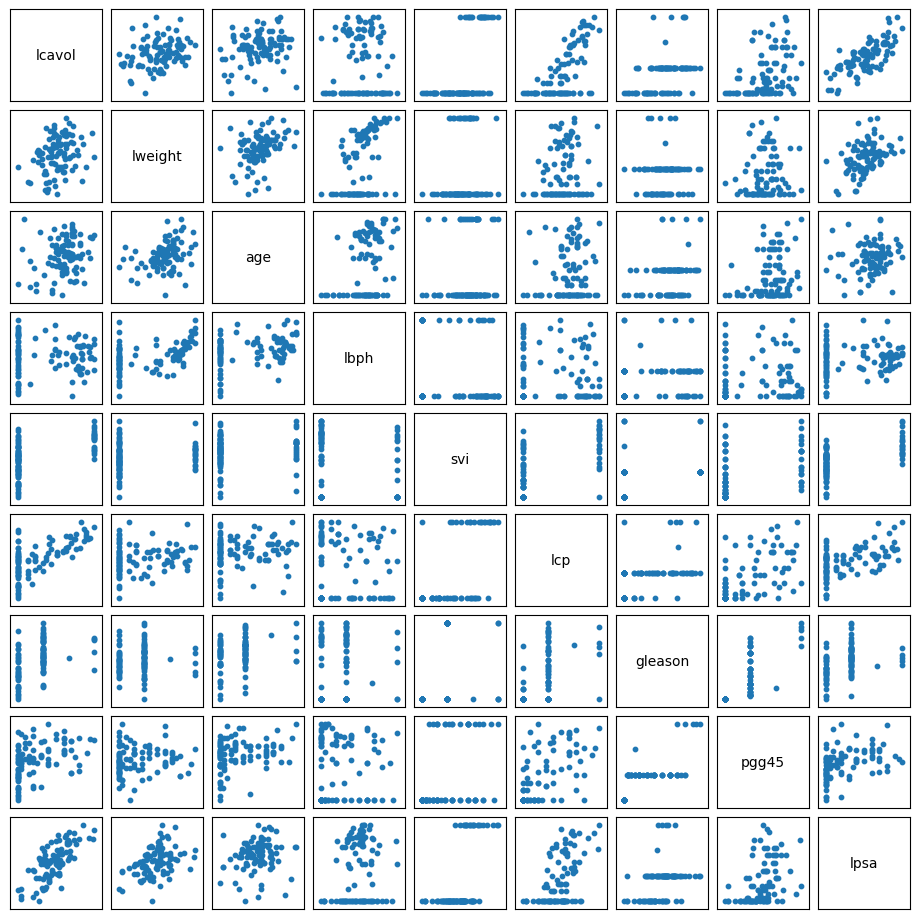

In [2]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        # if no sizes chosen, set it automatically
        figsize = (7.10, 6.70) # shape of the tiles
    # number of vars is number of columns of the dataframe panda
    n_vars = df.shape[1]
    # the subplots(tiles), on a matrix n_vars x n_vars
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    # adjusting the look of the plots
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    #iteration for each plot of the matrix
    for i in range(n_vars):
        for j in range(n_vars):
            # subplot i j
            axij = ax[i][j]
            # name of var i
            i_name = df.columns[i]
            # name of var j
            j_name = df.columns[j]
            # removing ticks axis for clear representation
            axij.set_xticks([])
            axij.set_yticks([])
            # small margin on subplot
            axij.margins(0.1)
            if i != j:
                # showing correlation on non diagonal tiles
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                # on diagonal tile, showing which variable is represented on this column or line
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df, (10.0, 10.0))
plt.show()

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

On pose
$$
X = \{x_1, \dots, x_n\} \\
Y = \{y_1, \dots, y_n\} \\
$$

Avec
$$
\bar{X} = \frac{1}{n} \times \sum_{i=1}^{n} x_i \\
\bar{Y} = \frac{1}{n} \times \sum_{i=1}^{n} y_i \\
$$

$$
\rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y} =
\frac{\sum_{i=1}^{n} (x_i - \bar{X})(y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{Y})^2}}
$$

Correlation (Numpy): 0.73446032621367307591
Correlation (Perso): 0.73446032621367285387
Error | correlation_perso - correlation_numpy | = 0.00000000000000022204


/home/maximet/miniconda3/envs/isla2026/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


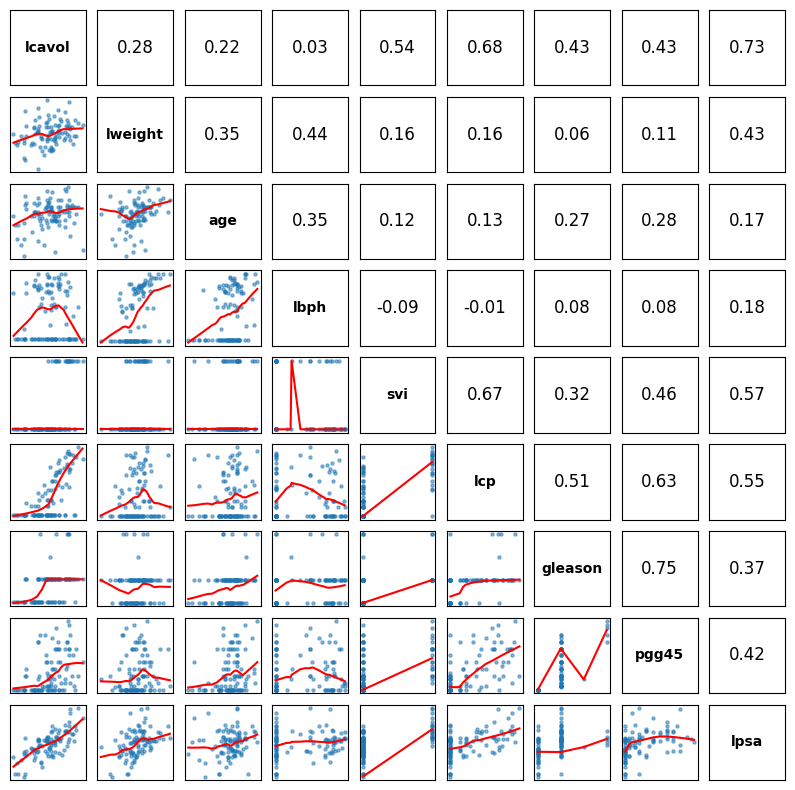

In [3]:
import numpy as np
#!pip install statsmodels
def correlation(x, y):
    # means
    mean_x, mean_y = np.mean(x), np.mean(y)
    
    # covariance
    cov = np.sum((x - mean_x) * (y - mean_y))
    
    # standard deviation
    standard_deviation = np.sqrt(np.sum((x - mean_x)**2) * np.sum((y - mean_y)**2))
    
    return cov / standard_deviation

correlation_numpy = correlation(df['lpsa'], df['lcavol'])
correlation_perso = df['lpsa'].corr(df['lcavol'])

print(f"Correlation (Numpy): {correlation_numpy:.20f}")
print(f"Correlation (Perso): {correlation_perso:.20f}")

print(f"Error | correlation_perso - correlation_numpy | = {abs(correlation_numpy - correlation_perso):.20f}")

from statsmodels.nonparametric.smoothers_lowess import lowess

def pairplot_enhanced(df, figsize=(10, 10)):
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.15, hspace=0.15)

    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name, j_name = df.columns[i], df.columns[j]
            axij.set_xticks([]); axij.set_yticks([])

            if i == j:
                # diag, name of var
                axij.text(0.5, 0.5, i_name, fontweight='bold', ha='center', va='center')
            
            elif i < j:
                # upper, correlation
                corr = df[i_name].corr(df[j_name])
                axij.text(0.5, 0.5, f"{corr:.2f}", fontsize=12, ha='center', va='center')
                
                
            else:
                #  lower LOWESS
                axij.scatter(df[j_name], df[i_name], s=5, alpha=0.5)
                z = lowess(df[i_name], df[j_name], frac=0.5)
                axij.plot(z[:, 0], z[:, 1], color='red', lw=1.5)

    return fig, ax

fig, ax = pairplot_enhanced(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [4]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

This is the mathematical equation of the regression model:

$$
y_i = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij} + \varepsilon_i \\
Y = X\beta + \varepsilon
$$

with:

* **$y_i$ (or $Y$)**: Response variable, representing the log of tumor volume (`lcavol`).
* **$x_{ij}$ (or $X$)**: Predictors (e.g., `lpsa`, `age`), where $X$ is the design matrix.
* **$\beta_0$**: The intercept, representing the value of $y$ when all predictors are zero.
* **$\beta_j$ (or $\beta$)**: Regression coefficients, representing the partial effect of each predictor on $y$ when the others are supposed constant.
* **$\varepsilon_i$ (or $\varepsilon$)**: Error term, assumed to follow a normal distribution $\varepsilon \sim \mathcal{N}(0, \sigma^2 I_n)$.

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [5]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

* **`dtype` in `pd.get_dummies`**: We fix it to `np.float64` to make it compatible with numerical linear algebra operations such as matrix inversion or multiplication used in OLS.
* **Dropping two columns**: We remove `svi_0` and `gleason_6` to avoid obteigning non inversible matrices since svi_0 + svi_1 = 1, and we are adding a collumn of 1, deleting some columns allows us to avoid this type of problem.
* **Column of ones**: We add it to represent the **intercept** ($\beta_0$) in the design matrix $X$, as `statsmodels.api.OLS` does not include it by default.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [6]:
#Check the python secions other this one, the two above are important for this python section
import statsmodels.api as sm


# Building model
model = sm.OLS(y, X)
# Fitting the model
results = model.fit()

# Displaying summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        17:04:08   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

* **`svi_1` (-0.2204)**: This coefficient represents the estimated change in `lcavol` for patients with seminal vesicle invasion (`svi=1`) compared to those without it (`svi=0`). In our results, the p-value is **0.392**, indicating that this effect is not statistically significant at the 5% level.
* **`gleason_7`, `gleason_8`, `gleason_9`**: These coefficients represent the impact of having a Gleason score of 7, 8, or 9 relative to the reference score of **6**. For example, a patient with a Gleason score of 9 has a predicted `lcavol` that is **0.7901** units higher than a patient with a score of 6, all else being equal.

#### 2. Effect of omitting One-Hot Encoding
If one-hot encoding had not been performed, the model would have treated `gleason` and `svi` as **continuous numerical variables**:

* For `gleason`, the model would have assumed a constant linear relationship (e.g., the "jump" from score 6 to 7 being identical to the jump from 8 to 9). 
* Since these are **qualitative/ordinal** scores, treating them as continuous would likely lead to **model bias**. One-hot encoding is necessary to allow the model to estimate a unique "step" for each level without assuming a linear trend.

#### 3. Overall Commentary on the Regression
* **Goodness of Fit**: The **R-squared of 0.686** indicates that the model explains approximately **68.6%** of the variance in the tumor volume (`lcavol`). The **Adjusted R-squared (0.650)** confirms that the variables are coherent.
* **Model Significance**: The **F-statistic (18.83)** has a highly significant p-value (**9.05e-18**), showing that the model is effective.
* **Significant Predictors**: 
    * **`lpsa`** (p < 0.001) and **`lcp`** (p < 0.001) are the strongest and most significant drivers.
    * **`age`** (p = 0.030) and **`pgg45`** (p = 0.040) are also significant at the 5% threshold.
* **Non-significant Predictors**: We see that **`lweight` (p = 0.958)** and **`svi_1`** appear to be irrelevant in this specific multivariate context, as we fail to reject the null hypothesis that their coefficients are zero.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [7]:
conf_intervals = results.conf_int(alpha=0.05)
conf_intervals.columns = ['Lower 95%', 'Upper 95%']
print(conf_intervals)

           Lower 95%  Upper 95%
lweight    -0.431600   0.409107
age         0.002436   0.047129
lbph       -0.219914   0.011515
lcp         0.233639   0.571880
pgg45      -0.018469  -0.000419
lpsa        0.370474   0.728673
svi_1      -0.730029   0.289190
gleason_7  -0.116263   0.739616
gleason_8  -2.219087   0.797911
gleason_9  -0.179004   1.759273
intercept  -3.145013   0.331705


1. **Variables excluding zero**: 
   - **`lpsa` [0.370, 0.729]** and **`lcp` [0.234, 0.572]** have intervals that are entirely positive. This confirms a statistically significant positive relationship with `lcavol`.
   - **`age` [0.002, 0.047]** also excludes zero, confirming its significance at the 5% level.
   - **`pgg45` [-0.018, -0.000]** is  negative, aligning with its small but significant p-value.

2. **Variables including zero**: 
   - Predictors such as **`lweight` [-0.432, 0.409]**, **`svi_1` [-0.730, 0.289]**, and all **`gleason`** have intervals that cross zero. 
   - For these variables, we cannot determine with 95% confidence whether the effect is positive or negative. This confirms that these predictors are not statistically significant in the current model.



**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [8]:
lpsa_pvalue = results.pvalues['lpsa']
lpsa_conf = results.conf_int().loc['lpsa']

print(f"lpsa p-value: {lpsa_pvalue:.4e}")
print(f"lpsa 95% Confidence Interval: [{lpsa_conf[0]:.3f}, {lpsa_conf[1]:.3f}]")

lpsa p-value: 2.9392e-08
lpsa 95% Confidence Interval: [0.370, 0.729]


The `lpsa` variable appears to be the most influential predictor in our model. We can draw the following conclusions:

1. **Statistical Significance ($p$-value)**:
   The $p$-value for `lpsa` is extremely small. In the context of a hypothesis test ($H_0: \beta_{lpsa} = 0$), we strongly reject the null hypothesis. This indicates that `lpsa` has a statistically significant effect on the tumor volume (`lcavol`).

2. **Confidence Interval**:
   The 95% confidence interval for the `lpsa` coefficient is **[0.370, 0.729]**. Since this interval is strictly positive and does not contain zero, we are 95% confident that an increase in `lpsa` is associated with an increase in `lcavol`. The fact that the interval is relatively narrow and far from zero suggests that our estimate is both precise and robust.

3. **Magnitude of Effect**:
   With a coefficient of approximately **0.55**, for every 1-unit increase in the log of PSA, the log of tumor volume is expected to increase by 0.55 units, provided all other variables remain constant. Clinically, this confirms that PSA levels are a very strong biomarker for predicting the severity of prostate cancer.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [9]:
import numpy as np
from scipy import stats

def manual_ols(X, y):
    # Convert to numpy arrays
    X_mat = X.to_numpy()
    y_vec = y.to_numpy()
    n, p = X_mat.shape # n observations, p predictors
    
    # 1. Estimate Beta coefficients using the equation: (X^T X) beta = X^T y
    XtX = X_mat.T @ X_mat
    Xty = X_mat.T @ y_vec
    beta_hat = np.linalg.solve(XtX, Xty)
    
    # 2. Calculate Residuals and Variance of the error (sigma squared)
    y_pred = X_mat @ beta_hat
    residuals = y_vec - y_pred
    RSS = np.sum(residuals**2)
    sigma_squared = RSS / (n - p) # divising by n - p in order to have an unbiased estimator since we used n observations that have each p degrees of information
    
    # 3. Calculate Standard Errors of the coefficients
    # Variance-Covariance matrix: sigma^2 * (X^T X)^-1
    C = np.linalg.inv(XtX)
    standard_errors = np.sqrt(sigma_squared * np.diagonal(C))
    
    # 4. Calculate t-statistics and p-values
    # t = beta / SE
    t_stats = beta_hat / standard_errors
    # p-value using t-distribution with (n-p) degrees of freedom, student test, "2 * .." because we are looking for extreme values
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))
    
    return beta_hat, p_values

betas, p_vals = manual_ols(X, y)

# Comparison with statsmodels
for i, col in enumerate(X.columns):
    print(f"{col:10} | Coef: {betas[i]:.4f} | p-value: {p_vals[i]:.4e}")

lweight    | Coef: -0.0112 | p-value: 9.5771e-01
age        | Coef: 0.0248 | p-value: 3.0150e-02
lbph       | Coef: -0.1042 | p-value: 7.6956e-02
lcp        | Coef: 0.4028 | p-value: 8.5779e-06
pgg45      | Coef: -0.0094 | p-value: 4.0477e-02
lpsa       | Coef: 0.5496 | p-value: 2.9392e-08
svi_1      | Coef: -0.2204 | p-value: 3.9227e-01
gleason_7  | Coef: 0.3117 | p-value: 1.5129e-01
gleason_8  | Coef: -0.7106 | p-value: 3.5167e-01
gleason_9  | Coef: 0.7901 | p-value: 1.0873e-01
intercept  | Coef: -1.4067 | p-value: 1.1137e-01


The coefficients $\hat{\beta}$ are calculated by solving:
$$(X^T X) \hat{\beta} = X^T Y$$
The p-values are derived from the $t$-statistic $t_j = \frac{\hat{\beta}_j}{\hat{se}(\hat{\beta}_j)}$, which follows a Student's t-distribution with $n-p$ degrees of freedom.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

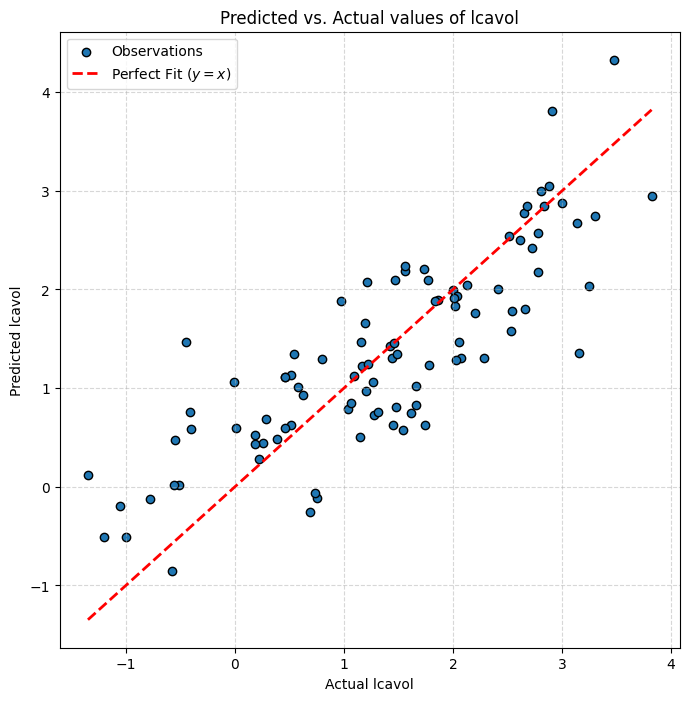

In [10]:
import matplotlib.pyplot as plt

# Predictions from the model
predictions = results.get_prediction(X)
y_pred = predictions.predicted_mean

# Plotting Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred, edgecolors='k', label='Observations')

# Add the y=x line (Perfect prediction line), the  closer the predictions are to this line, the better the prediction is(or overfit...)
line_coords = [y.min(), y.max()]
plt.plot(line_coords, line_coords, 'r--', lw=2, label='Perfect Fit ($y=x$)')

# Labels and Title
plt.xlabel('Actual lcavol')
plt.ylabel('Predicted lcavol')
plt.title('Predicted vs. Actual values of lcavol')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

Residual Sum of Squares (RSS): 41.8141


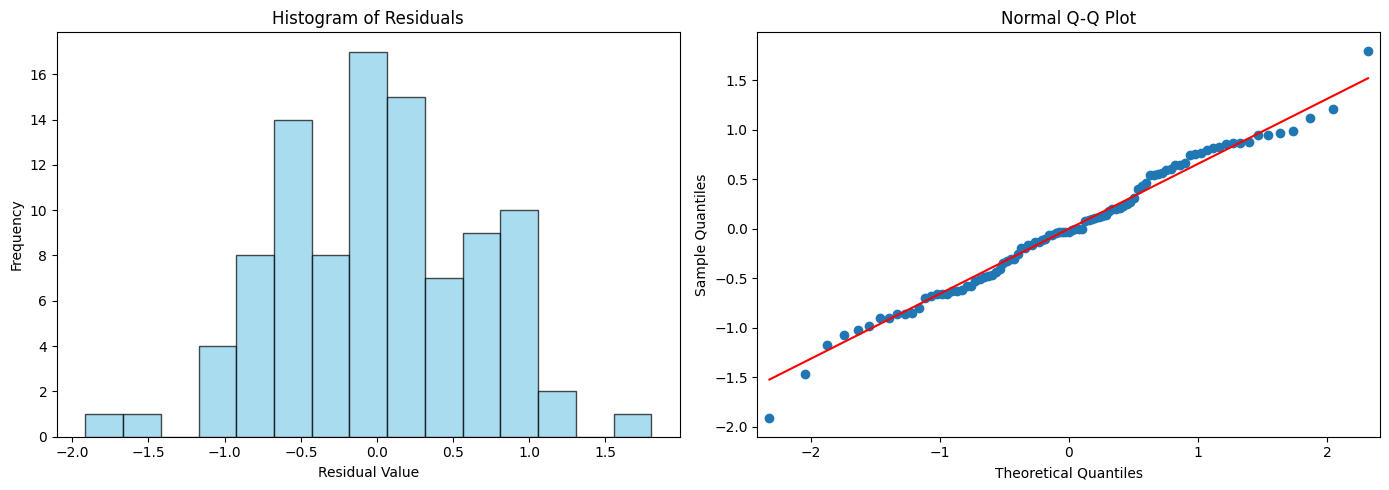

In [11]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# (h) Compute residuals and RSS
residuals = results.resid
RSS = np.sum(residuals**2)

print(f"Residual Sum of Squares (RSS): {RSS:.4f}")

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram of Residuals
ax1.hist(residuals, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Residual Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Residuals')

# 2. QQ-plot
sm.qqplot(residuals, line='s', ax=ax2)
ax2.set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

### Analysis of Residuals

#### Residual Sum of Squares (RSS)
The calculated **RSS is 41.8** (approx). This value represents the total unexplained variation in the `lcavol` variable by the current model.

#### Normality Assessment
One of the fundamental assumptions of linear regression is that the residuals $\varepsilon$ are normally distributed: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

* **Histogram**: The histogram shows a bell-shaped distribution centered around zero.
* **Q-Q Plot**: The points in the Normal Q-Q plot follow the theoretical 45-degree line quite closely.


**Conclusion**: We can admit that the residuals are **normally distributed**. This validates the use of $t$-tests and $p$-values for determining the significance of our predictors in the previous questions.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [12]:
# i
cols_to_drop = ['lpsa', 'lcp']
X_reduced = X.drop(columns=cols_to_drop)

# Fit models
model_reduced = sm.OLS(y, X_reduced)
results_reduced = model_reduced.fit()

print("--- Full Model ---")
print(f"R-squared:      {results.rsquared:.4f}")
print(f"Adj. R-squared: {results.rsquared_adj:.4f}")
print(f"RSS:            {results.ssr:.4f}") # RSS

print("\n--- Reduced Model (No lpsa and lcp) ---")
print(f"R-squared:      {results_reduced.rsquared:.4f}")
print(f"Adj. R-squared: {results_reduced.rsquared_adj:.4f}")
print(f"RSS:            {results_reduced.ssr:.4f}") # RSS new model
print(f"F-statistic p-value: {results_reduced.f_pvalue:.4e}")

# increase of RSS in %
rss_increase = ((results_reduced.ssr - results.ssr) / results.ssr) * 100
print(f"\nRSS Increase: {rss_increase:.2f}%")

--- Full Model ---
R-squared:      0.6865
Adj. R-squared: 0.6500
RSS:            41.8141

--- Reduced Model (No lpsa and lcp) ---
R-squared:      0.4327
Adj. R-squared: 0.3811
RSS:            75.6532
F-statistic p-value: 2.1104e-08

RSS Increase: 80.93%


### Impact of removing `lpsa` and `lcp`

By removing the two most significant predictors, `lpsa` and `lcp`, we can observe the following changes in the model's performance:

1. **Explanatory Power**: The **R-squared** dropped from **0.6865** to **0.4327**. This indicates that these two variables alone were responsible for explaining roughly **25%** of the total variance in the tumor volume (`lcavol`).
2. **Model Robustness**: The **Adjusted R-squared** fell from **0.6500** to **0.3811**. Since the Adjusted $R^2$ accounts for the number of predictors, this sharp decline confirms that the remaining variables do not compensate for the loss of `lpsa` and `lcp`.
3. **Statistical Significance**: Even though the model has weakened, the **F-statistic p-value (2.11e-08)** remains very low. This means that the remaining variables (like `age` and `pgg45`) still provide a better prediction than a simple average, but the model is far less precise.
4. **RSS**: We can see that without **lpsa** and **lcp** the calculated **RSS** is about **75.65** whereas it was **41.81** before. The **increase** is about **80.93%** which show how important these variables are.

**Conclusion**: 
While the reduced model is still statistically "better than nothing," `lpsa` and `lcp` are clearly the **dominant predictors**. Their removal leads to a significant loss of information, highlighting their critical importance in clinical cancer prognosis.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

In [13]:
# a
import itertools

def find_best_subset(X, y, k):
    predictors = [col for col in X.columns if col != 'intercept']
    # In order to store each RSS for each combinaison
    results = []
    
    # CASE k=0: Intercept only
    if k == 0:
        model = sm.OLS(y, X[['intercept']]).fit()
        # Create a tiny DataFrame so we can return (row, dataframe) like the other cases
        df_results = pd.DataFrame([{'predictors': ('intercept',), 'RSS': model.ssr}])
        return df_results.iloc[0], df_results

    # CASE k > 0: All combinations
    for combo in itertools.combinations(predictors, k):
        X_subset = X[list(combo) + ['intercept']]
        model = sm.OLS(y, X_subset).fit()
        results.append({'predictors': combo, 'RSS': model.ssr})
    
    df_results = pd.DataFrame(results)
    best_idx = df_results['RSS'].idxmin()
    return df_results.iloc[best_idx], df_results

# Solve for a
k = 2
best_row, all_combos = find_best_subset(X, y, k)

print(f"{'Combination of ' + str(k) + ' Predictors':<45} | {'RSS':<10}")
print("-" * 60)
for index, row in all_combos.iterrows():
    combo_str = ", ".join(row['predictors'])
    print(f"{combo_str:<45} | {row['RSS']:.4f}")

print("-" * 60)
print(f"BEST MODEL (k={k}): {best_row['predictors']}")
print(f"MINIMUM RSS: {best_row['RSS']:.4f}")

Combination of 2 Predictors                   | RSS       
------------------------------------------------------------
lweight, age                                  | 120.4025
lweight, lbph                                 | 121.3140
lweight, lcp                                  | 68.6076
lweight, pgg45                                | 100.8950
lweight, lpsa                                 | 61.1871
lweight, svi_1                                | 89.3453
lweight, gleason_7                            | 103.2961
lweight, gleason_8                            | 122.8620
lweight, gleason_9                            | 119.1287
age, lbph                                     | 126.2055
age, lcp                                      | 69.9302
age, pgg45                                    | 106.6807
age, lpsa                                     | 60.0357
age, svi_1                                    | 91.1062
age, gleason_7                                | 107.2066
age, gleason_8                 

We found that the best variables are **lcp** and **lpsa** as we already explained before ! In deed there is a RSS of 47.28 which is the minimum RSS for k = 2.

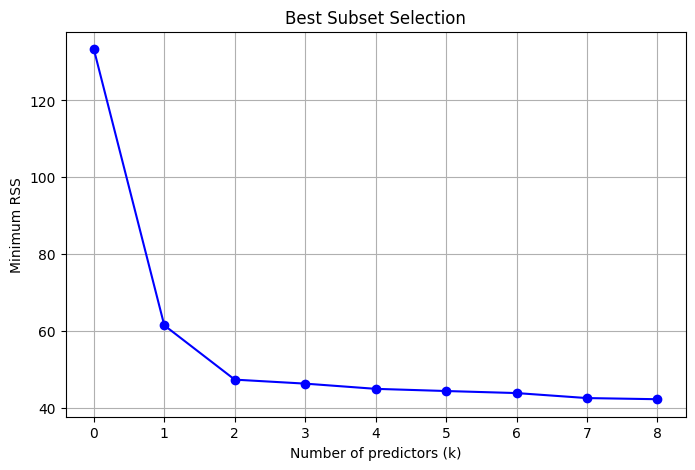

   k         RSS                                         predictors
0  0  133.359034                                          intercept
1  1   61.420907                                               lpsa
2  2   47.278097                                          lcp, lpsa
3  3   46.237825                                     age, lcp, lpsa
4  4   44.878406                               age, lbph, lcp, lpsa
5  5   44.311332                        age, lbph, lcp, pgg45, lpsa
6  6   43.776021             age, lbph, lcp, pgg45, lpsa, gleason_8
7  7   42.473641  age, lbph, lcp, pgg45, lpsa, gleason_7, gleason_9
8  8   42.173933  age, lbph, lcp, pgg45, lpsa, gleason_7, gleaso...


In [14]:
# (b) Best predictors for each k from 0 to 8
best_per_k = []

for k in range(0, 9):
    best_row, _ = find_best_subset(X, y, k)
    best_per_k.append({
        'k': k, 
        'RSS': best_row['RSS'], 
        'predictors': ", ".join(best_row['predictors'])
    })

df_best_final = pd.DataFrame(best_per_k)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(df_best_final['k'], df_best_final['RSS'], 'o-b')
plt.xlabel('Number of predictors (k)')
plt.ylabel('Minimum RSS')
plt.title('Best Subset Selection')
plt.grid(True)
plt.show()

print(df_best_final)

c.
RSS is not the best, since adding more variables will just create some overfitting at some point.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.